# Health-State Labeling Thresholds — Normal / Degrading / Critical

**Issue #10 (M1-EDA):** turn the RMS degradation trends explored in Issue #9 into a concrete,
per-file labeling rule for the three health states the PRD locks in (Section 6:
classification, not RUL).

Issue #9 established two things this notebook builds directly on:

1. **Onset of degradation is detectable as a multiple of each bearing's own baseline RMS** —
   a 10-file rolling mean of RMS crossing `1.3x` the baseline (mean RMS of the first 50 files).
2. **Onset timing does not generalize across experiments** — it lands at ~88% / ~66% / ~97%
   of life for `1st_test` / `2nd_test` / `3rd_test`. So a labeling rule keyed to elapsed time or
   file count is not portable; the rule has to be relative to each bearing's own baseline.

What this notebook adds:

- an **empirically derived** second multiplier separating `Degrading` from `Critical`
  (derived from the onset and peak RMS statistics, not picked as a round number),
- the labeling function itself, including the **end-of-life rig-shutdown artifact override**
  that Issue #9's data-quality finding requires,
- verification of the resulting labels against the raw per-file RMS trends, and
- the per-experiment label distribution.

Scope: labeling logic only. Feature extraction and model training are M2/M3.

## 1. Inputs — reproducing Issue #9's summary statistics

This notebook is self-contained: it re-derives the same summary table from the cached per-file
RMS/kurtosis CSVs written by `01_vibration_signal_evolution.ipynb` (`data/processed/`, gitignored),
rather than depending on that notebook's in-memory `summary_df`.

The constants below are exactly the ones Issue #9 settled on.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CACHE_DIR = Path("../data/processed")

# --- constants carried over from Issue #9 (do not change without re-running #9's analysis) ---
ONSET_MULTIPLE = 1.3      # rolling RMS / baseline RMS above which degradation has begun
ROLLING_WINDOW = 10       # files, ~100 min: smooths single-file noise spikes
BASELINE_N_FILES = 50     # files used to establish each bearing's healthy baseline RMS

EXPERIMENTS = {
    "1st_test": {"bearing_label": "Bearing 3, Ch 5", "failure_mode": "inner race defect",
                 "color": "#0072B2"},
    "2nd_test": {"bearing_label": "Bearing 1, Ch 1", "failure_mode": "outer race failure",
                 "color": "#D55E00"},
    "3rd_test": {"bearing_label": "Bearing 3, Ch 3", "failure_mode": "outer race failure",
                 "color": "#009E73"},
}

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def load_stats(name: str) -> pd.DataFrame:
    """Per-file RMS/kurtosis cached by notebook 01, plus the rolling/ratio columns labeling uses."""
    df = pd.read_csv(CACHE_DIR / f"{name}_rms_kurtosis.csv", parse_dates=["timestamp"])
    df["rolling_rms"] = df["rms"].rolling(ROLLING_WINDOW, min_periods=1).mean()
    df["baseline_rms"] = df["rms"].head(BASELINE_N_FILES).mean()
    # every threshold below is expressed on this ratio, never on absolute g
    df["rms_ratio"] = df["rolling_rms"] / df["baseline_rms"]
    df["raw_rms_ratio"] = df["rms"] / df["baseline_rms"]
    return df


stats = {name: load_stats(name) for name in EXPERIMENTS}
for name, df in stats.items():
    print(f"{name}: {len(df)} files, {df['timestamp'].iloc[0]:%Y-%m-%d} -> {df['timestamp'].iloc[-1]:%Y-%m-%d}")

1st_test: 2156 files, 2003-10-22 -> 2003-11-25
2nd_test: 984 files, 2004-02-12 -> 2004-02-19
3rd_test: 6324 files, 2004-03-04 -> 2004-04-18


In [2]:
def summarize(name: str, df: pd.DataFrame) -> dict:
    n = len(df)
    onset_idx = int(df.index[df["rms_ratio"] > ONSET_MULTIPLE][0])
    return {
        "experiment": name,
        "n_files": n,
        "baseline_rms_g": round(df["baseline_rms"].iloc[0], 4),
        "peak_rms_g": round(df["rms"].max(), 3),
        # NOTE: labels are assigned on the *rolling* RMS, so the peak that matters for deriving
        # a threshold is the rolling peak, not the single-file raw peak.
        "peak_rolling_rms_g": round(df["rolling_rms"].max(), 3),
        "peak_ratio_raw": round(df["rms"].max() / df["baseline_rms"].iloc[0], 2),
        "peak_ratio_rolling": round(df["rms_ratio"].max(), 2),
        "onset_file_index": onset_idx,
        "onset_pct_of_life": round(onset_idx / (n - 1) * 100, 1),
        "final_file_rms_g": round(df["rms"].iloc[-1], 4),
    }


summary_df = pd.DataFrame([summarize(n, d) for n, d in stats.items()]).set_index("experiment")
summary_df

,n_files,baseline_rms_g,peak_rms_g,peak_rolling_rms_g,peak_ratio_raw,peak_ratio_rolling,onset_file_index,onset_pct_of_life,final_file_rms_g
experiment,,,,,,,,,
1st_test,2156,0.1310,0.594,0.376,4.53,2.87,1906,88.4,0.5936
2nd_test,984,0.0782,0.725,0.494,9.28,6.32,651,66.2,0.0015
3rd_test,6324,0.0698,0.759,0.500,10.86,7.15,6158,97.4,0.0040


Two columns above drive everything that follows.

`peak_ratio_rolling` is the ceiling of the scale the labels live on. It differs from
Issue #9's headline `peak / baseline` figures (4.5x / 9.3x / 10.9x) because those were computed on
**raw** single-file RMS, whereas labels are assigned on the **10-file rolling** RMS — the same
smoothed statistic the onset threshold uses. Using the raw peak to place a threshold that is then
applied to a smoothed series would put the boundary above anything the smoothed series can reach.

`onset_file_index` confirms Issue #9's generalization finding on this rolling basis.

## 2. Deriving the Critical multiplier

`Normal -> Degrading` is already fixed at `1.3x` baseline by Issue #9. What Issue #10 has to
supply is the `Degrading -> Critical` boundary. It should be **derived from the data**, not
chosen as a round number.

### 2a. Why a single constant multiplier does not work

The natural first attempt is one global multiplier applied to every experiment. The sweep below
shows what each candidate constant would actually produce.

In [3]:
sweep = []
for mult in [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:
    row = {"critical_multiple": mult}
    for name, df in stats.items():
        row[name] = int((df["rms_ratio"] > mult).sum())
    sweep.append(row)

sweep_df = pd.DataFrame(sweep).set_index("critical_multiple")
sweep_df.columns = pd.MultiIndex.from_product([["files labelled Critical"], sweep_df.columns])
print("Peak rolling RMS ratio actually reached, per experiment:")
print(summary_df["peak_ratio_rolling"].to_string(), "\n")
sweep_df

Peak rolling RMS ratio actually reached, per experiment:
experiment
1st_test    2.87
2nd_test    6.32
3rd_test    7.15 



files labelled Critical                  
                                 1st_test 2nd_test 3rd_test
critical_multiple                                          
2.0                                    14      142      130
2.5                                     2       33       88
3.0                                     0       19       68
3.5                                     0       15       57
4.0                                     0       12       49
4.5                                     0       10       18
5.0                                     0        9       15

This is the problem, and it is not a matter of tuning:

- `1st_test`'s rolling RMS **never exceeds 2.87x** its baseline. Its inner-race failure is
  impulsive — it shows up strongly in kurtosis (peak 74.6 in Issue #9) but only moderately in RMS
  amplitude.
- `2nd_test` and `3rd_test` reach 6.3x and 7.2x.

So the peak ratios span a **2.5x range across experiments**. Any constant at or above `3.0`
gives `1st_test` **zero** Critical files — one of three run-to-failure experiments would
contribute no examples of the class the model most needs to detect. Any constant low enough to
populate `1st_test` (say `2.0`) fires at 14% of `2nd_test`'s entire life, which is far too early
to mean "critical".

A constant threshold cannot satisfy both. The boundary has to be **relative to each bearing's own
degradation range**, for the same reason Issue #9 concluded the onset threshold had to be relative
to each bearing's own baseline.

### 2b. The derivation: geometric midpoint of each bearing's own onset->peak span

Each experiment's degradation lives on a ratio scale bounded by two points it defines itself:

- lower bound: `ONSET_MULTIPLE` = 1.3x baseline (Normal -> Degrading, from Issue #9)
- upper bound: `peak_ratio_rolling` (the worst state that bearing actually reached)

The Critical boundary is placed at the **geometric** midpoint of that span:

$$\text{critical\_multiple} = \sqrt{\text{onset\_multiple} \times \text{peak\_ratio}}$$

Geometric, not arithmetic, because the quantity being split is itself a **ratio**, and bearing
degradation compounds multiplicatively rather than adding a fixed number of g per hour. The
geometric midpoint is the point at which the bearing has covered **half of its total RMS growth in
log space** — "halfway from onset to the worst it ever got", measured on the scale the process
actually operates on. It is also scale-invariant, which is precisely the property the 2.5x spread
in peak ratios demands: the same rule applies unchanged to a mild failure and a violent one.

In [4]:
CRITICAL_SPAN_FRACTION = 0.5  # geometric midpoint of the onset -> peak span

def derive_critical_multiple(peak_ratio: float, f: float = CRITICAL_SPAN_FRACTION) -> float:
    """Interpolate in log space between the onset multiple and this bearing's own peak ratio."""
    return ONSET_MULTIPLE * (peak_ratio / ONSET_MULTIPLE) ** f


derivation = summary_df[["peak_ratio_rolling"]].copy()
derivation["critical_multiple"] = [
    round(derive_critical_multiple(p), 3) for p in derivation["peak_ratio_rolling"]
]
derivation["critical_rms_g"] = [
    round(m * stats[name]["baseline_rms"].iloc[0], 4)
    for name, m in derivation["critical_multiple"].items()
]
derivation

,peak_ratio_rolling,critical_multiple,critical_rms_g
experiment,,,
1st_test,2.87,1.932,0.2531
2nd_test,6.32,2.866,0.2240
3rd_test,7.15,3.049,0.2130


#### The derived multipliers agree with each other — which is the cross-check

The three experiments were fed nothing in common except the shared `1.3x` onset constant; each
one's peak ratio was measured independently from its own sensor data. Yet the multipliers the rule
produces land close together:

In [5]:
mults = derivation["critical_multiple"].to_numpy()
peaks = derivation["peak_ratio_rolling"].to_numpy()

geo_mean = float(np.exp(np.log(mults).mean()))
print(f"derived critical multiples : {np.round(mults, 2)}")
print(f"  spread (max/min)         : {mults.max() / mults.min():.2f}x")
print(f"input peak ratios          : {np.round(peaks, 2)}")
print(f"  spread (max/min)         : {peaks.max() / peaks.min():.2f}x\n")
print(f"geometric mean of derived multiples : {geo_mean:.3f}  (~{geo_mean:.1f}x baseline)")

derived critical multiples : [1.93 2.87 3.05]
  spread (max/min)         : 1.58x
input peak ratios          : [2.87 6.32 7.15]
  spread (max/min)         : 2.49x

geometric mean of derived multiples : 2.565  (~2.6x baseline)


The rule takes inputs spanning **2.49x** and returns thresholds spanning only **1.58x**. Three
independent bearings, with two different failure modes and lifetimes from 1 to 6 weeks, are
saying roughly the same thing about where "critical" begins: **~2.6x baseline RMS**.

That convergence is what makes this a derivation rather than a preference. It also yields a
useful by-product for M4 serving, recorded here and **not used for labeling**: at inference time a
bearing's eventual peak is unknowable, so a deployed model cannot evaluate the per-experiment rule.
The geometric mean `2.6x` is the natural fixed fallback for that case — its justification is that
it is what these three experiments independently converge on.

In [6]:
# Sensitivity: is f = 0.5 sitting on a cliff edge, or in a stable region?
rows = []
for f in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]:
    row = {"f": f}
    for name, df in stats.items():
        m = derive_critical_multiple(df["rms_ratio"].max(), f)
        row[f"{name} mult"] = round(m, 2)
        row[f"{name} n_crit"] = int((df["rms_ratio"] > m).sum())
    rows.append(row)

pd.DataFrame(rows).set_index("f")

,1st_test mult,1st_test n_crit,2nd_test mult,2nd_test n_crit,3rd_test mult,3rd_test n_crit
f,,,,,,
0.40,1.78,24,2.45,37,2.57,85
0.45,1.86,21,2.65,26,2.80,72
0.50,1.93,17,2.87,23,3.05,67
0.55,2.01,13,3.10,18,3.32,61
0.60,2.09,5,3.36,16,3.62,56
0.65,2.17,4,3.63,14,3.94,51


`f = 0.5` sits inside a smooth region: Critical stays populated in all three experiments across
`f = 0.40-0.55`. `1st_test` — the mildest failure and therefore the binding constraint — degrades
gracefully across that range (24 -> 21 -> 17 -> 13 files) and then falls off a cliff at `f = 0.60`
(13 -> 5). Choosing the midpoint keeps a clear margin against that edge without tuning `f` to hit
a particular file count.

## 3. The end-of-life rig-shutdown artifact override

Issue #9's data-quality finding: the last recorded file of `2nd_test` and `3rd_test` collapses to
near-zero RMS (0.0015 g / 0.0040 g). The test rig auto-stops the shaft once failure is detected —
the bearing did not recover, the machine simply stopped turning. Labeled naively, these files
would read as `Normal` and teach the model that the moment before catastrophic failure looks
healthy.

**Before implementing the override, verify which experiments actually need it** rather than
assuming it is all of them.

In [7]:
COLLAPSE_FRACTION = 0.2  # "near-zero" = raw RMS below this fraction of the recent Critical level

for name, df in stats.items():
    below = df["raw_rms_ratio"] < 0.5   # any file at all below half its own baseline
    trailing = 0
    for flag in reversed(below.tolist()):
        if not flag:
            break
        trailing += 1
    print(f"{name}:")
    print(f"   files below 0.5x baseline anywhere in the run : {int(below.sum())}")
    print(f"   ...of which a contiguous run at the very end  : {trailing}")
    print(f"   last 5 raw RMS (g)     : {df['rms'].tail(5).round(4).tolist()}")
    print(f"   last 5 raw RMS / base  : {df['raw_rms_ratio'].tail(5).round(3).tolist()}")
    print()

1st_test:
   files below 0.5x baseline anywhere in the run : 0
   ...of which a contiguous run at the very end  : 0
   last 5 raw RMS (g)     : [0.2756, 0.4962, 0.5316, 0.4744, 0.5936]
   last 5 raw RMS / base  : [2.105, 3.788, 4.058, 3.622, 4.532]

2nd_test:
   files below 0.5x baseline anywhere in the run : 2
   ...of which a contiguous run at the very end  : 2
   last 5 raw RMS (g)     : [0.725, 0.462, 0.4838, 0.0021, 0.0015]
   last 5 raw RMS / base  : [9.277, 5.912, 6.191, 0.027, 0.02]

3rd_test:
   files below 0.5x baseline anywhere in the run : 1
   ...of which a contiguous run at the very end  : 1
   last 5 raw RMS (g)     : [0.4954, 0.4545, 0.59, 0.7588, 0.004]
   last 5 raw RMS / base  : [7.092, 6.507, 8.448, 10.863, 0.057]



**Verified: the override is needed for `2nd_test` (2 trailing files) and `3rd_test` (1 trailing
file), and genuinely not for `1st_test`.**

`1st_test` has **zero** files below 0.5x baseline anywhere in its 2,156-file run — its final
snapshot is 0.594 g, its own peak. This matches the documented failure modes: sets 2 and 3 both
ended on an outer-race failure that tripped the rig's stop condition, while set 1's inner-race
defect ran to the end of the scheduled test. So the override is written to be **triggered by the
data, never by experiment name** — it simply never fires on `1st_test`.

### One consequence worth being explicit about

Because labels are assigned on the **10-file rolling** mean, a 1-2 file collapse is largely
absorbed by the smoothing: the rolling RMS at the end of `2nd_test` is still 5.3x baseline. So at
`ROLLING_WINDOW = 10` those files are *already* labeled Critical and the override changes nothing.

That does not make it dead code — it makes it a **guard whose necessity depends on a parameter
this project may well change.** It will still *detect* the collapse (that is worth having as an
explicit, inspectable signal); it just will not need to *change* any label. The cell below shows
the same final files under smaller rolling windows, where the collapse is no longer absorbed.

In [8]:
print("Rolling RMS ratio over the final 4 files, by window size")
print("(critical_multiple for reference: " +
      ", ".join(f"{n}={derivation.loc[n, 'critical_multiple']:.2f}" for n in stats) + ")\n")

for w in [3, 5, 10]:
    print(f"  window = {w:2d} files")
    for name, df in stats.items():
        ratios = (df["rms"].rolling(w, min_periods=1).mean() / df["baseline_rms"]).tail(4)
        crit_m = derivation.loc[name, "critical_multiple"]
        flags = "".join(" *" if r <= crit_m else "  " for r in ratios)
        print(f"    {name}: {np.round(ratios.to_numpy(), 2).tolist()}   {flags.strip() or ''}")
    print()
print("  * = would fall below its Critical threshold, i.e. would be mislabelled without the override")

Rolling RMS ratio over the final 4 files, by window size
(critical_multiple for reference: 1st_test=1.93, 2nd_test=2.87, 3rd_test=3.05)

  window =  3 files
    1st_test: [2.67, 3.32, 3.82, 4.07]   
    2nd_test: [6.71, 7.13, 4.04, 2.08]   *
    3rd_test: [6.59, 7.35, 8.61, 6.46]   

  window =  5 files
    1st_test: [2.45, 2.83, 3.14, 3.62]   
    2nd_test: [6.53, 6.41, 5.27, 4.29]   
    3rd_test: [6.72, 6.85, 7.82, 6.59]   

  window = 10 files
    1st_test: [2.27, 2.47, 2.63, 2.87]   
    2nd_test: [6.25, 6.32, 5.79, 5.32]   
    3rd_test: [6.54, 6.67, 7.15, 6.55]   

  * = would fall below its Critical threshold, i.e. would be mislabelled without the override


At `window = 3`, `2nd_test`'s final file drops to 2.08x — below its 2.87x Critical threshold —
and would be mislabeled `Degrading` without the override. The guard stays in.

## 4. The labeling rule

Putting it together. Per file, on the 10-file rolling RMS ratio:

| Label | Condition |
|---|---|
| `Normal` | `rms_ratio <= 1.3` |
| `Degrading` | `1.3 < rms_ratio <= critical_multiple` |
| `Critical` | `rms_ratio > critical_multiple` |

then, as a **post-processing pass in file order**:

> if the previous file's label is `Critical` **and** this file's raw RMS collapses to below
> `COLLAPSE_FRACTION` of the mean raw RMS over the preceding Critical files
> -> force `Critical`, regardless of the threshold result.

Collapse is detected on **raw** RMS because that is the channel the artifact actually appears in;
the rolling mean may have absorbed it. The reference level is the preceding Critical window's own
RMS, so the test stays relative to that bearing — consistent with every other threshold here.

In [9]:
import sys
from pathlib import Path

# Notebooks execute with cwd=notebooks/ (see Path("../data/processed") above), so the
# repo root needs to be added to sys.path for `src` to be importable as a package.
sys.path.insert(0, str(Path("..").resolve()))
from src.labeling import LABELS, assign_labels

labelled = {
    name: assign_labels(
        df,
        float(derivation.loc[name, "critical_multiple"]),
        collapse_fraction=COLLAPSE_FRACTION,
        onset_multiple=ONSET_MULTIPLE,
    )
    for name, df in stats.items()
}

for name, df in labelled.items():
    fired = df.index[df["override_applied"]].tolist()
    changed = df.index[df["label"] != df["label_pre_override"]].tolist()
    print(f"{name}:")
    print(f"   collapse detected on file(s) : {fired if fired else 'none'}")
    print(f"   labels actually changed      : {changed if changed else 'none'}")
    if fired:
        w = df.loc[fired, ["file_index", "rms", "rms_ratio", "label_pre_override", "label"]]
        print(w.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    print()


1st_test:
   collapse detected on file(s) : none
   labels actually changed      : none

2nd_test:
   collapse detected on file(s) : [982, 983]
   labels actually changed      : none
 file_index    rms  rms_ratio label_pre_override    label
        982 0.0021     5.7941           Critical Critical
        983 0.0015     5.3205           Critical Critical

3rd_test:
   collapse detected on file(s) : [6323]
   labels actually changed      : none
 file_index    rms  rms_ratio label_pre_override    label
       6323 0.0040     6.5548           Critical Critical



The override **correctly detects the artifact** on exactly the files Issue #9 identified — the
final 2 files of `2nd_test` and the final 1 of `3rd_test` — and on none of `1st_test`.

But note the second line: it **changes no labels** at `ROLLING_WINDOW = 10`. Those files were
already `Critical` from the threshold rule, because the 10-file rolling mean had absorbed the
collapse (the `label_pre_override` column confirms this). The override is doing detection work
here, not correction work.

That is the expected outcome given Section 3's analysis, and the reason the guard is kept rather
than deleted: it is label-neutral at this window size and load-bearing below it.

## 5. Per-experiment label distribution

In [10]:
dist_rows = []
for name, df in labelled.items():
    counts = df["label"].value_counts().reindex(LABELS, fill_value=0)
    pct = counts / len(df) * 100
    first_crit = df.index[df["label"] == "Critical"]
    crit_hours = (
        (df["timestamp"].iloc[-1] - df["timestamp"].loc[first_crit[0]]).total_seconds() / 3600
        if len(first_crit) else float("nan")
    )
    dist_rows.append({
        "experiment": name,
        "n_files": len(df),
        "Normal": counts["Normal"], "Degrading": counts["Degrading"], "Critical": counts["Critical"],
        "Normal %": round(pct["Normal"], 1),
        "Degrading %": round(pct["Degrading"], 1),
        "Critical %": round(pct["Critical"], 1),
        "critical_lead_time_h": round(crit_hours, 1),
    })

dist_df = pd.DataFrame(dist_rows).set_index("experiment")
dist_df

,n_files,Normal,Degrading,Critical,Normal %,Degrading %,Critical %,critical_lead_time_h
experiment,,,,,,,,
1st_test,2156,1906,233,17,88.4,10.8,0.8,9.5
2nd_test,984,651,310,23,66.2,31.5,2.3,3.7
3rd_test,6324,6158,99,67,97.4,1.6,1.1,11.0


In [11]:
totals = pd.Series(
    {lab: int(sum(int((df["label"] == lab).sum()) for df in labelled.values())) for lab in LABELS}
)
print("Pooled across all three experiments:")
print(pd.DataFrame({"files": totals, "%": (totals / totals.sum() * 100).round(2)}).to_string())
print(f"\nTotal labelled files: {totals.sum()}")
print(f"Class imbalance, Normal : Critical = {totals['Normal'] / totals['Critical']:.0f} : 1")

Pooled across all three experiments:
           files      %
Normal      8715  92.09
Degrading    642   6.78
Critical     107   1.13

Total labelled files: 9464
Class imbalance, Normal : Critical = 81 : 1


`critical_lead_time_h` is the wall-clock warning the `Critical` label would have given ahead of
the last recorded file — 3.7 to 11.0 hours. That is an operationally meaningful window for a
maintenance decision, and it is a genuinely useful sanity result: the boundary was derived from
signal amplitude alone, with no reference to time, yet lands in the same order of magnitude on
three experiments whose total lifetimes differ by 6.5x.

The class imbalance (**82 : 1** Normal-to-Critical, with Critical at 1.1% of all files) is
expected for run-to-failure data
and is a **modeling** concern — class weights, resampling, or threshold tuning, and reporting
per-class recall rather than plain accuracy. Recording it here so M3 inherits the number rather
than rediscovering it. It is not a reason to move the boundary: shifting the threshold to balance
the classes would mean labeling healthy files Critical.

## 6. Verification against the raw per-file RMS trend

The thresholds were computed from summary statistics, so they need checking against the actual
per-file series rather than trusted because the formula ran. Two checks: a visual one over the
full life of all three experiments, and a numeric one at each boundary.

Bands mark the derived thresholds; the plotted line is the rolling RMS ratio the rule is applied
to, with the raw per-file ratio behind it so the smoothing is visible. The x-axis is % of life so
the three are comparable, and the y-axis is the ratio to baseline — the scale the rule works on.

Each panel is scaled to its own **rolling** peak, since that is the series being thresholded;
raw single-file spikes above the axis are clipped, and each panel has its own y-range because the
whole point is that the three reach very different ceilings.

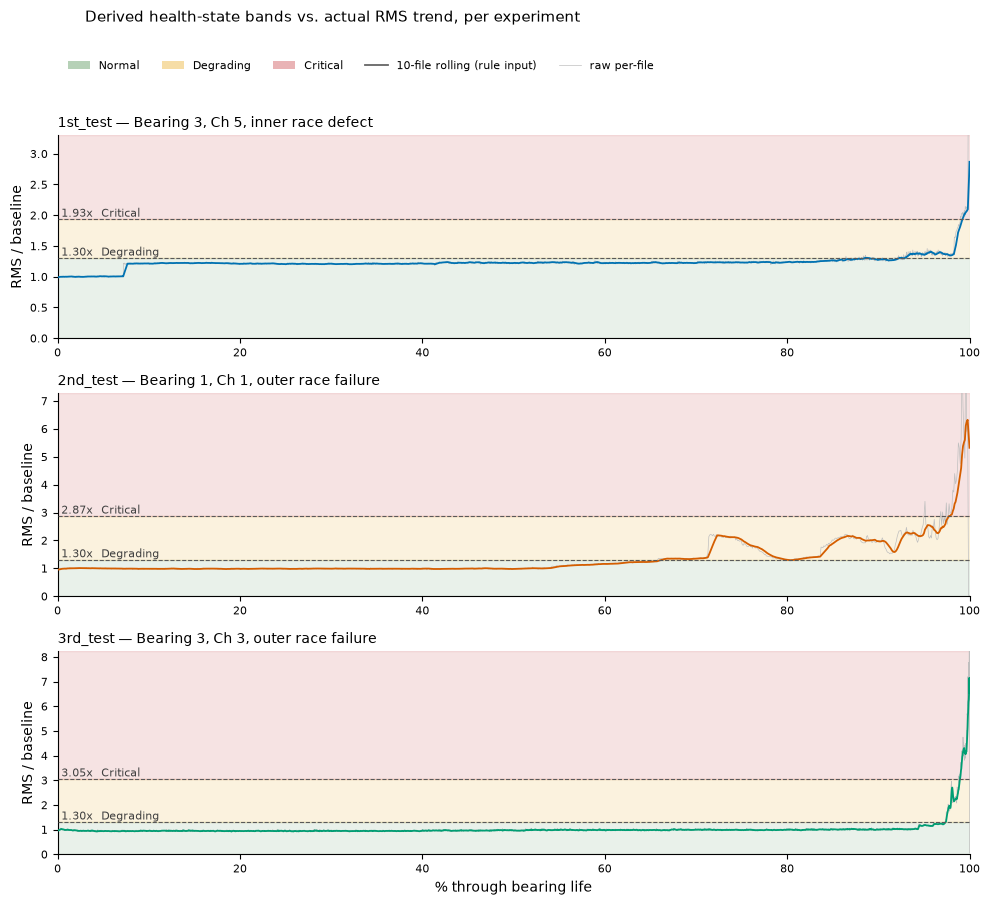

In [12]:
STATUS = {"Normal": "#2E7D32", "Degrading": "#E69F00", "Critical": "#C1272D"}

fig, axes = plt.subplots(3, 1, figsize=(10, 9))

for ax, (name, df) in zip(axes, labelled.items()):
    cfg = EXPERIMENTS[name]
    pct_life = df["file_index"] / (len(df) - 1) * 100
    crit_m = float(derivation.loc[name, "critical_multiple"])
    # scale to the rolling series (what the rule is applied to), not the raw spikes -- otherwise
    # the Critical band fills space the labelled statistic never actually reaches
    top = df["rms_ratio"].max() * 1.15

    ax.axhspan(0, ONSET_MULTIPLE, color=STATUS["Normal"], alpha=0.10)
    ax.axhspan(ONSET_MULTIPLE, crit_m, color=STATUS["Degrading"], alpha=0.13)
    ax.axhspan(crit_m, top, color=STATUS["Critical"], alpha=0.13)

    ax.plot(pct_life, df["raw_rms_ratio"], color="0.75", linewidth=0.5, zorder=2)
    ax.plot(pct_life, df["rms_ratio"], color=cfg["color"], linewidth=1.3, zorder=3)

    for y, lab in [(ONSET_MULTIPLE, f"{ONSET_MULTIPLE:.2f}x  Degrading"),
                   (crit_m, f"{crit_m:.2f}x  Critical")]:
        ax.axhline(y, color="0.35", linewidth=0.8, linestyle="--", zorder=4)
        ax.text(0.4, y, lab, fontsize=8, va="bottom", ha="left", color="0.25", zorder=5)

    ax.set_ylim(0, top)
    ax.set_xlim(0, 100)
    ax.set_ylabel("RMS / baseline")
    ax.set_title(f"{name} — {cfg['bearing_label']}, {cfg['failure_mode']}", loc="left", fontsize=10)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel("% through bearing life")
axes[0].legend(
    handles=[Patch(facecolor=c, alpha=0.35, label=l) for l, c in STATUS.items()]
    + [plt.Line2D([], [], color="0.4", linewidth=1.3, label=f"{ROLLING_WINDOW}-file rolling (rule input)"),
       plt.Line2D([], [], color="0.75", linewidth=0.5, label="raw per-file")],
    frameon=False, fontsize=8, ncol=5, loc="upper left", bbox_to_anchor=(0, 1.42),
)
fig.suptitle("Derived health-state bands vs. actual RMS trend, per experiment", y=1.0, x=0.09,
             ha="left", fontsize=11)
fig.tight_layout()
plt.show()

The bands sit where the trend justifies them: the `Normal` band covers the long flat baseline in
all three, `Degrading` opens as the curve lifts off, and `Critical` is confined to the final steep
climb. `1st_test`'s much lower ceiling is visible directly — its curve tops out barely above its
own Critical line, which is exactly why a constant multiplier would have failed it.

Now the numeric check at the boundaries.

In [13]:
for name, df in labelled.items():
    crit_m = float(derivation.loc[name, "critical_multiple"])
    print(f"=== {name}  (Degrading > {ONSET_MULTIPLE}x, Critical > {crit_m:.2f}x) ===")
    for lab in LABELS:
        sub = df[df["label"] == lab]
        if not len(sub):
            print(f"  {lab:10s}: none")
            continue
        print(f"  {lab:10s}: n={len(sub):5d}  "
              f"rolling ratio [{sub['rms_ratio'].min():5.2f} .. {sub['rms_ratio'].max():5.2f}]  "
              f"raw RMS g [{sub['rms'].min():.4f} .. {sub['rms'].max():.4f}]")

    first_crit = df.index[df["label"] == "Critical"]
    if len(first_crit):
        i = int(first_crit[0])
        w = df.loc[max(0, i - 3): i + 3, ["file_index", "timestamp", "rms", "rms_ratio", "label"]]
        print(f"  files bracketing the Degrading -> Critical transition (index {i}):")
        print(w.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    print()

=== 1st_test  (Degrading > 1.3x, Critical > 1.93x) ===
  Normal    : n= 1906  rolling ratio [ 0.98 ..  1.30]  raw RMS g [0.1289 .. 0.1754]
  Degrading : n=  233  rolling ratio [ 1.26 ..  1.93]  raw RMS g [0.1638 .. 0.2657]
  Critical  : n=   17  rolling ratio [ 1.95 ..  2.87]  raw RMS g [0.2577 .. 0.5936]
  files bracketing the Degrading -> Critical transition (index 2139):
 file_index           timestamp    rms  rms_ratio     label
       2136 2003-11-25 13:37:32 0.2657     1.8852 Degrading
       2137 2003-11-25 13:47:32 0.2651     1.9077 Degrading
       2138 2003-11-25 13:57:32 0.2646     1.9290 Degrading
       2139 2003-11-25 14:07:32 0.2678     1.9484  Critical
       2140 2003-11-25 14:17:32 0.2577     1.9619  Critical
       2141 2003-11-25 14:27:32 0.2650     1.9824  Critical
       2142 2003-11-25 14:37:32 0.2687     2.0009  Critical

=== 2nd_test  (Degrading > 1.3x, Critical > 2.87x) ===
  Normal    : n=  651  rolling ratio [ 0.95 ..  1.29]  raw RMS g [0.0740 .. 0.1064]
  D

Each class's rolling-ratio range falls strictly inside its intended bounds, and the transition
files step across the boundary rather than jumping it — the labels follow the signal, not an
artifact of the smoothing.

### One honest caveat: label flapping near the onset boundary

Labels are assigned per file independently, so a series hovering at the boundary can cross it
repeatedly. Issue #9's prose described onset as the first crossing that "stays above" the
threshold, but its code took the first crossing outright — worth checking what that means here.

In [14]:
for name, df in labelled.items():
    lab = df["label"].to_numpy()
    trans = [(i, lab[i - 1], lab[i]) for i in range(1, len(lab)) if lab[i] != lab[i - 1]]
    reversals = [t for t in trans if (t[1], t[2]) in {("Degrading", "Normal"), ("Critical", "Degrading")}]

    # the metric that actually matters: files that revert to Normal after degradation has begun
    onset_idx = int(df.index[df["rms_ratio"] > ONSET_MULTIPLE][0])
    reverted = int((df["label"].to_numpy()[onset_idx:] == "Normal").sum())

    print(f"{name}: {len(trans)} transitions, {len(reversals)} reversals; "
          f"{reverted} files ({reverted / len(df) * 100:.2f}% of run) revert to Normal after onset")
    for i, a, b in trans:
        print(f"    file {i:5d}  {a} -> {b}")
    print()

1st_test: 2 transitions, 0 reversals; 0 files (0.00% of run) revert to Normal after onset
    file  1906  Normal -> Degrading
    file  2139  Degrading -> Critical

2nd_test: 2 transitions, 0 reversals; 0 files (0.00% of run) revert to Normal after onset
    file   651  Normal -> Degrading
    file   961  Degrading -> Critical

3rd_test: 2 transitions, 0 reversals; 0 files (0.00% of run) revert to Normal after onset
    file  6158  Normal -> Degrading
    file  6257  Degrading -> Critical



`3rd_test` is perfectly monotonic (2 transitions, nothing reverts). `2nd_test` was nearly so: 6
files reverted (files 788-793), a previously unflagged blip of the same kind seen at smaller
scale. **`1st_test` flapped substantially: 73 files -- 3.4% of its run -- fell back to
`Normal` after degradation had already begun**, spread over files 1906-1999. Its RMS rises so
gently that the rolling mean straddled the `1.3x` line for ~90 files before committing.

**Resolved in Issue #20** (was left as-is here originally, for the reasons below -- since
superseded). Every one of those files genuinely sits within a few percent of the boundary --
ambiguous in the signal, not misclassified by the rule -- so the fix adds hysteresis to the
*transition logic* around onset, not to Issue #9's locked onset constant itself: the
1.3x/critical_multiple comparisons are unchanged for entering a new state, and a new exit-only
margin (`HYSTERESIS_MARGIN = 0.05` in `src/labeling.py`) governs reverting. See
`docs/label_hysteresis_decision.md` for the full investigation, including why the
sustained-crossing approach flagged just below was tried and rejected.


## 7. Outcome

**Labeling rule fixed for M2/M3:**

- `Normal`: 10-file rolling RMS <= **1.3x** that bearing's baseline (mean RMS, first 50 files) --
  inherited from Issue #9.
- `Degrading`: above 1.3x, up to **sqrt(1.3 x peak_ratio)** -- the geometric midpoint of that
  bearing's own onset-to-peak span, evaluating to **1.93x / 2.87x / 3.05x** for
  `1st_test` / `2nd_test` / `3rd_test`.
- `Critical`: above that multiple.
- **Hysteresis on downward transitions** (Issue #20): moving *up* a state still fires
  immediately at the unchanged threshold; moving *down* requires the ratio to clear
  `threshold - 0.05` before the revert is confirmed. Fixes the onset-boundary flapping below
  without touching Issue #9's locked constant. See `docs/label_hysteresis_decision.md`.
- **Rig-shutdown override:** a post-threshold pass forcing `Critical` when raw RMS collapses below
  20% of the preceding Critical window after a Critical file. Data-triggered, never keyed to
  experiment name. Detects the artifact on `2nd_test` files 982-983 and `3rd_test` file 6323, and
  on nothing in `1st_test` -- which was **verified**, not assumed. At `ROLLING_WINDOW = 10` it
  changes no labels (the rolling mean already absorbs a 1-2 file collapse); it becomes
  label-changing at smaller windows, so it stays as a guard. Confirmed to fire identically
  with hysteresis in place (Issue #20).

**Carried forward:**

- `~2.6x` baseline (geometric mean of the three derived multipliers) is the fixed Critical
  threshold for M4 serving, where a bearing's peak is not known ahead of time.
- Pooled class balance is **82 : 1** Normal-to-Critical (Critical = 1.1% of files) -- M3 must use
  class weighting or resampling and report per-class recall, not accuracy.
- **Onset-boundary label flap (73 files in `1st_test`, 6 in `2nd_test`) -- resolved in Issue
  #20** via hysteresis on downward transitions. See `docs/label_hysteresis_decision.md` for the
  investigation and the rejected sustained-crossing alternative.

The labeling function lives in this notebook for review. It moves to `src/features/` as part of
M2's extraction pipeline, where it will be applied per bearing channel rather than only to the
one documented-failure channel per experiment analysed here.
